# Purpose

This notebook demonstrates the model experimentation and finalization. It covers EDA, outlier treatment, transformation, training, model evaluation and comparison across models.

## Imports

In [78]:
import os
import os.path as op
import shutil

# standard third party imports
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

# impute missing values
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import KNNImputer, IterativeImputer, SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from category_encoders import TargetEncoder


In [79]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
import warnings

warnings.filterwarnings('ignore', message="pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.", 
                        category=FutureWarning)


In [81]:
# standard code-template imports
from ta_lib.core.api import (
    create_context, get_dataframe, get_feature_names_from_column_transformer, string_cleaning,
    get_package_path, display_as_tabs, save_pipeline, load_pipeline, initialize_environment,
    load_dataset, save_dataset, DEFAULT_ARTIFACTS_PATH
)

import ta_lib.eda.api as eda
from xgboost import XGBRegressor
from ta_lib.regression.api import SKLStatsmodelOLS
from ta_lib.regression.api import RegressionComparison, RegressionReport
import ta_lib.reports.api as reports
from ta_lib.data_processing.api import Outlier

initialize_environment(debug=False, hide_warnings=True)

# Initialization

In [82]:
artifacts_folder = DEFAULT_ARTIFACTS_PATH

In [84]:
config_path = op.join('conf', 'config.yml')
context = create_context(config_path)

# 3 Feature Engineering

The focus here is the `Pipeline` and not the model. Though the model would inform the pipeline that is needed to train the model, our focus is to set it up in such a way that it can be saved/loaded, tweaked for different model choices and so on.

## 3.1 Read the Train and Test Data

In [85]:
train_X = load_dataset(context, 'train/housing/features')
train_y = load_dataset(context, 'train/housing/target')
print(train_X.shape, train_y.shape)

test_X = load_dataset(context, 'test/housing/features')
test_y = load_dataset(context, 'test/housing/target')
print(test_X.shape, test_y.shape)

(16512, 9) (16512, 1)
(4128, 9) (4128, 1)


## 3.2 Feature Engineering Pipelines


**Dev NOTES**

For Feature Engineering and Model Building sklearn.pipeline.Pipeline are leveraged because of the following advantages
<details>
    
1. It helps in automating workflows and are easier to read and comprehend.
2. Right Sequence can be ensured and (for example always encodes before imputing)
3. Reproducibility is very convenient with pipelines
4. Pipelines help you prevent data leakage in your test data
5. Code is near implementation ready

#### General Steps in the Feature Transformation are as follows
 - Outlier Treatment
 - Encoding of Categorical Columns
 - Missing Values Imputation

In [86]:
# collecting different types of columns for transformations
cat_columns = train_X.select_dtypes('object').columns
num_columns = train_X.select_dtypes('number').columns

In [87]:
cat_columns

Index(['ocean_proximity'], dtype='object')

#### Outlier Handling
- A Custom Transformer is used to handle outliers. It is not included as part of the pipeline as outliers handling are optional for test data
- An option to either drop or cap the outliers can be passed during the transform call
- If we want to treat outliers for some columns them we can pass cols argument to the Transformer
- This will go into production code

In [88]:
outlier_transformer = Outlier(method='mean')
print(train_X.shape)
train_X = outlier_transformer.fit_transform(train_X)
print(train_X.shape)

(16512, 9)
(16512, 9)


#### Encoding


Some sample pipelines showcasing how to create column specific pipelines and integrating them overall is presented below

- Commonly target encoding is done for categorical variables with too many levels.
- We also group sparse levels. For fewer levels one hot encoding/label encoding is preferred.
- If there is one dominant level, we can use binary encoding.
- This will go into production code

In [89]:
from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # nothing else to do
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]

        else:
            return np.c_[X, rooms_per_household, population_per_household]

In [90]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

num_pipeline = Pipeline([
        ('simple_impute', SimpleImputer(strategy="median")),
        ('attribs_adder', CombinedAttributesAdder()),
        ('std_scaler', StandardScaler()),
    ])

#housing_num_tr = num_pipeline.fit_transform(num_columns)

from sklearn.compose import ColumnTransformer

num_attribs = list(num_columns)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),
    ])

#train_X_prepared = full_pipeline.fit_transform(train_X)

**Dev notes(Encoding):**
<details>

    Some common practices followed in Categorical Feature Encoding are
    * For categorical variables with too many levels, target encoding can be done.
    * For fewer levels, one hot encoding can be done.
    * If one very dominant level is observed, binary encoding can be used.
    
    
</details>

## 3.2 Feature analysis

Using the pipeline above analyze the features and decide on additional features to add/remove from the pipeline. This section will not be part of the production code, unless input data drifts etc. are explicitly demanded in the project.

Here we are primarily focused on feature selection/elimination based on business rules, prior knowledge, data analysis.

**We are not building any models at this point.**


- we create some sample data to analyze that we assume represent the population
- train the features transformer and do the analysis as below

In [91]:
sample_X = train_X.sample(frac=0.1, random_state=context.random_seed)
sample_y = train_y.loc[sample_X.index]

sample_train_X = get_dataframe(
    full_pipeline.fit_transform(sample_X, sample_y), 
    ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'rooms_per_household', 'population_per_household', 'bedrooms_per_room',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN']
)

# nothing to do for target
sample_train_y = sample_y

In [92]:
sample_train_X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,population_per_household,bedrooms_per_room,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.416091,1.015602,0.128101,-0.434729,0.628304,0.300176,0.637553,-1.697436,-0.725338,-0.461602,2.921852,0.0,0.0,0.0,1.0,0.0
1,0.779238,-0.850582,0.363356,0.417009,0.344262,0.363333,0.337367,-0.114238,-0.004739,-0.048930,-0.262157,1.0,0.0,0.0,0.0,0.0
2,1.209404,-1.371810,-0.185573,0.040879,0.701511,1.510312,0.905460,-1.010986,-0.532993,0.529586,1.170231,0.0,0.0,0.0,0.0,1.0
3,0.789127,-0.855236,0.284938,-0.155133,0.107073,-0.006588,0.146927,-0.088580,-0.309789,-0.307372,0.464968,1.0,0.0,0.0,0.0,0.0
4,-0.793092,1.480985,-0.656083,-0.268148,-0.449298,-0.718233,-0.556734,0.159076,0.289556,-0.493600,-0.571061,0.0,1.0,0.0,0.0,0.0


Running the features transformer on the complete data

In [93]:
train_X = get_dataframe(
    full_pipeline.fit_transform(train_X, train_y), 
    ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'rooms_per_household', 'population_per_household', 'bedrooms_per_room',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN']
)

### 3.2.1 Univariate


- Look at each variable independently. This is useful if your models have assumptions on the distribution and/or bounds on the features/target

In [94]:
out = eda.get_density_plots(train_X, cols=['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'rooms_per_household', 'population_per_household', 'bedrooms_per_room',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'])
out

:DynamicMap   [col]
   :Layout
      .Overlay.I :Overlay
         .Histogram.I    :Histogram   [x]   (Frequency)
         .Distribution.I :Distribution   [longitude]   (Density)
      .Table.I   :Table   [count,mean,std,min,25%,50%,75%,max]

In [95]:
# save the plots are html
reports.create_report({'univariate': out}, name='feature_analysis_univariate')

A report containing the above plot is available [here](https://drive.google.com/file/d/16ntqUc_zvpg0at5pTtO-ljBjw5UVGFnp/view?usp=sharing)


Alternatively, the above plots can be generated as a single html as below. The output from this is available [here](https://drive.google.com/file/d/1vUaCcs1PJ4IYo1em9-eZIEj9WuDsnFKT/view?usp=sharing)

In [96]:
reports.feature_analysis(train_X,'./feature_analysis_report.html')

p-value may not be accurate for N > 5000.
this method is deprecated in favour of `Styler.to_html()`


### 3.2.2 Bivariate - mutual interactions

- Find columns with high correlations and drop them

In [97]:
out = eda.get_correlation_table(train_X)
out[out["Abs Corr Coef"] > 0.6]

,Variable 1,Variable 2,Corr Coef,Abs Corr Coef
0,households,total_bedrooms,0.973557,0.973557
1,latitude,longitude,-0.924918,0.924918
2,total_bedrooms,total_rooms,0.919087,0.919087
3,households,total_rooms,0.913502,0.913502
4,households,population,0.907971,0.907971
5,population,total_bedrooms,0.873697,0.873697
6,population,total_rooms,0.844430,0.844430
7,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,-0.606939,0.606939


In [98]:
# households and total_bedrooms highly correlated. So discarding households
# total_bedrooms and total_rooms are almost same so discarding total_rooms.
# Similarly keeping latitude between longitude and latitude
# Similarly keeping households between households and total_rooms
# Similarly keeping households between households and population
# Similarly keeping ocean_proximity_<1H OCEAN between ocean_proximity_INLAND and ocean_proximity_<1H OCEAN

curated_columns = list(
    set(train_X.columns.to_list()) 
    - set(['households', 'total_rooms', 'longitude', 'population',
           'ocean_proximity_INLAND'])
)

train_X = train_X[curated_columns]

out = eda.get_correlation_table(train_X)
out[out["Abs Corr Coef"] > 0.6]

,Variable 1,Variable 2,Corr Coef,Abs Corr Coef


In [99]:
out = eda.get_bivariate_plots(train_X)
out

Column
    [0] Markdown(str)
    [1] Row
        [0] HoloViews(DynamicMap)
        [1] Column
            [0] WidgetBox
                [0] Select(margin=(20, 20, 5, 20), name='x_var', options=['housing_median_age', ...], value='housing_median_age', width=250)
                [1] Select(margin=(5, 20, 20, 20), name='y_var', options=['housing_median_age', ...], value='housing_median_age', width=250)
            [1] VSpacer()
    [2] Markdown(str)
    [3] Row
        [0] HoloViews(DynamicMap)
        [1] Column
            [0] WidgetBox
                [0] Select(margin=(20, 20, 5, 20), name='x_var', options=['ocean_proximity_NEAR BAY...], value='ocean_proximity_NEAR B..., width=250)
                [1] Select(margin=(5, 20, 20, 20), name='y_var', options=['housing_median_age', ...], value='housing_median_age', width=250)
            [1] VSpacer()
    [4] Markdown(str)
    [5] Row
        [0] HoloViews(DynamicMap)
        [1] Column
            [0] WidgetBox
                [0] Select(margin=(20, 20, 5, 20), name='x_var', options=['housing_median_age', ...], value='housing_median_age', width=250)
                [1] Select(margin=(5, 20, 20, 20), name='y_var', options=['ocean_proximity_NEAR BAY...], value='ocean_proximity_NEAR B..., width=250)
            [1] VSpacer()
    [6] Markdown(str)
    [7] Row
        [0] HoloViews(DynamicMap)
        [1] Column
            [0] WidgetBox
                [0] Select(margin=(20, 20, 5, 20), name='x_var', options=['ocean_proximity_NEAR BAY...], value='ocean_proximity_NEAR B..., width=250)
                [1] Select(margin=(5, 20, 20, 20), name='y_var', options=['ocean_proximity_NEAR BAY...], value='ocean_proximity_NEAR B..., width=250)
            [1] VSpacer()

In [100]:
%%time
# create reports as needed
cols = train_X.columns.to_list()
all_plots = {}
for ii, col1 in enumerate(cols): 
    for jj in range(ii+1, len(cols)):
        col2 = cols[jj]
        out = eda.get_bivariate_plots(train_X, x_cols=[col1], y_cols=[col2])
        all_plots.update({f'{col2} vs {col1}': out})

reports.create_report(all_plots, name='feature_analysis_bivariate')


CPU times: total: 27 s
Wall time: 34 s


A report containing the bivariate plot is available [here](https://drive.google.com/file/d/1WSGT3586tY-rOmZ57xGILbmL5ll9cSVT/view?usp=sharing)

Alternatively, the above plots can be generated as a single html as below. The output from this is available [here](https://drive.google.com/file/d/1A2fz_bjYv8I3iaFDT75JQSDKeJEXxCtp/view?usp=sharing)

In [101]:
reports.feature_interactions(train_X,'./feature_interaction_report.html')

this method is deprecated in favour of `Styler.to_html()`


### 3.2.3 Key Drivers - Interaction with Target variable

In [102]:
out = eda.get_target_correlation(train_X, train_y)
display_as_tabs([(k, v) for k,v in out.items()])

Tabs
    [0] HoloViews(Bars, name='feature_correlation')

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


Tabs
    [0] HoloViews(Bars, name='from_model')
    [1] Matplotlib(Figure, name='shap_values')
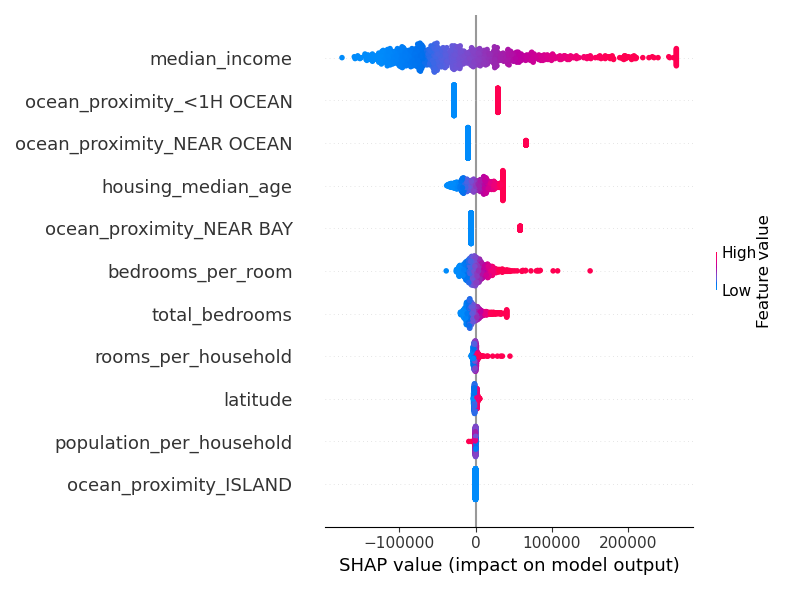

In [103]:
out = eda.get_feature_importances(train_X, train_y, y_continuous=True)
display_as_tabs([(k, v) for k,v in out.items()])

Key drivers report like feature importance, bivariate plots can be obtained as below

In [104]:
reports.key_drivers(train_X,train_y, './key_drivers_report.html', y_continuous=True)

**Dev Notes**
<details>
    
- The SHAP plots and bivariate plots in key drivers reports can be obtained by including quick=False as a parameter to key_drivers function call. 
- SHAP plots and bivariate plots often take long depending on data shape.
- The plot with shap is present [here](https://drive.google.com/file/d/1JOTMBLiv3LEqZ-kxZz0RokW9v5UyiGva/view?usp=sharing)

</details>


All the plots like feature analysis, interaction, key drivers can be obtained as a single plot using data exploration method as shown below. The output from this is available [here](https://drive.google.com/file/d/1209MzmSSEhiTYuPfHpaVXFXUVbkaJm0B/view?usp=sharing)

In [105]:
reports.data_exploration(train_X,train_y,'./data_exploration_report.html', y_continuous=True)

p-value may not be accurate for N > 5000.
this method is deprecated in favour of `Styler.to_html()`


In [106]:
# saving the list of relevant columns
save_pipeline(curated_columns, op.abspath(op.join(artifacts_folder, 'curated_columns.joblib')))

# save the feature pipeline
save_pipeline(full_pipeline, op.abspath(op.join(artifacts_folder, 'features.joblib')))

# 4 Modelling

## 4.1 Modelling - Linear Regression

### 4.1.1 Feature Selection(Specific to Regression)

- Selecting Features specific to regression
- VIF : measure of the amount of multi-collinearity in a set of multiple regressor variables. 
- On a case to case basis VIF thresholds change. Generally 5 or 10 are acceptable levels.
- Usually on a recursive basis when removing the most collinear variable, there can be shuffle in VIF. 
- Often this section will not be part of the production code.

In [107]:
cols = list(train_X.columns)
vif = eda.calc_vif(train_X)
while max(vif.VIF) > 15:
    #removing the largest variable from VIF
    cols.remove(vif[(vif.VIF==vif.VIF.max())].variables.tolist()[0])
    vif = eda.calc_vif(train_X[cols])

In [108]:
reg_vars = vif.query('VIF < 15').variables
reg_vars = list(reg_vars)

In [109]:
reg_vars

['housing_median_age',
 'total_bedrooms',
 'ocean_proximity_NEAR BAY',
 'latitude',
 'bedrooms_per_room',
 'ocean_proximity_NEAR OCEAN',
 'ocean_proximity_<1H OCEAN',
 'median_income',
 'rooms_per_household',
 'ocean_proximity_ISLAND',
 'population_per_household']

### 4.1.2 Data transformations

In [110]:
# Custom Transformations like these can be utilised
def _custom_data_transform(df, cols2keep=None):
    """Transformation to drop some columns in the data
    
    Parameters
    ----------
        df - pd.DataFrame
        cols2keep - columns to keep in the dataframe
    """
    cols2keep = cols2keep or []
    if len(cols2keep):
        return (df
                .select_columns(cols2keep))
    else:
        return df

### 4.1.3 Model training pipeline

- Here we focus on creating a collection of pipelines that can be used for training respective models.
- Each model pipeline will essentially be of the form
```
[
('preprocessing', preprocessing_pipeline),
('feature_selection', feature_selection_pipeline),
('estimator', estimator),
]
```

### 4.1.4 Model Pipeline Build

- This will be part of the production code (training only).

In [111]:
reg_ppln_ols = Pipeline([
    ('feature_selection',FunctionTransformer(_custom_data_transform, kw_args={'cols2keep':reg_vars})),
    ('estimator', SKLStatsmodelOLS())
])
reg_ppln_ols.fit(train_X, train_y.values.ravel())

Pipeline(steps=[('feature_selection',
                 FunctionTransformer(func=<function _custom_data_transform at 0x0000028CC6DFD040>,
                                     kw_args={'cols2keep': ['housing_median_age',
                                                            'total_bedrooms',
                                                            'ocean_proximity_NEAR '
                                                            'BAY',
                                                            'latitude',
                                                            'bedrooms_per_room',
                                                            'ocean_proximity_NEAR '
                                                            'OCEAN',
                                                            'ocean_proximity_<1H '
                                                            'OCEAN',
                                                            'median_income',
                 

In [112]:
reg_ppln_ols['estimator'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.631
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     2566.
Date:                Sun, 01 Sep 2024   Prob (F-statistic):               0.00
Time:                        18:03:01   Log-Likelihood:            -2.0767e+05
No. Observations:               16512   AIC:                         4.154e+05
Df Residuals:                   16500   BIC:                         4.155e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
intercept                   1.629e+05   1119.262    145.548      0.000    1.61e+05    1.65e+05
housing_median_age          1.831e+04    630.201     29.061      0.000    1.71e+04    1.95e+04
total_bedrooms               1.18e+04    589.393     20.021      0.000    1.06e+04     1.3e+04
ocean_proximity_NEAR BAY    6.613e+04   2145.577     30.820      0.000    6.19e+04    7.03e+04
latitude                    2274.5112    672.676      3.381      0.001     955.994    3593.028
bedrooms_per_room           1.708e+04    728.051     23.467      0.000    1.57e+04    1.85e+04
ocean_proximity_NEAR OCEAN  7.823e+04   1975.402     39.602      0.000    7.44e+04    8.21e+04
ocean_proximity_<1H OCEAN   5.925e+04   1566.210     37.829      0.000    5.62e+04    6.23e+04
median_income               8.499e+04    752.813    112.900      0.000    8.35e+04    8.65e+04
rooms_per_household         3891.6870    612.630      6.352      0.000    2690.865    5092.509
ocean_proximity_ISLAND      2.552e+05   3.51e+04      7.265      0.000    1.86e+05    3.24e+05
population_per_household   -4839.4568    547.209     -8.844      0.000   -5912.046   -3766.868
==============================================================================
Omnibus:                     3903.310   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            11645.055
Skew:                           1.226   Prob(JB):                         0.00
Kurtosis:                       6.304   Cond. No.                         89.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 4.1.5 Model Evaluation(Linear Model)

This will be part of the production code.

In [113]:
reg_ppln = Pipeline([
    #('', FunctionTransformer(_custom_data_transform, kw_args={'cols2keep':reg_vars})),
    ('Linear Regression', SKLStatsmodelOLS())
])

test_X = get_dataframe(
    full_pipeline.transform(test_X), 
    ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income','ocean_proximity_<1H OCEAN',
       'rooms_per_household', 'population_per_household', 'bedrooms_per_room', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN']
)
test_X = test_X[curated_columns]

In [114]:
reg_linear_report = RegressionReport(model=reg_ppln, x_train=train_X, y_train=train_y, x_test= test_X, y_test= test_y, refit=True)
reg_linear_report.get_report(include_shap=False, file_path='regression_linear_model_report')

Attribute `_pairwise` was deprecated in version 0.24 and will be removed in 1.1 (renaming of 0.26).
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
this method is deprecated in favour of `Styler.to_html()`


**Dev Notes**
Use SHAP for variable interpretability.
<details>

    1. Use SHAP=True to generate variable interpretability plots in the report
    2. SHAP is recommended for non parameteric models such as RF, xgboost.
    3. However, SHAP reports are time consuming depending on no.of records and model complexity.
    
A sample of regerssion report with SHAP can be found [here](https://drive.google.com/file/d/18RlQTsT1ze09Cgz-qpb4ha_cvyWbN5F5/view?usp=sharing).
</details>

### 4.1.6 Residual Analysis
- After scoring the model, it is recommended to do a residual analysis to know the distribution of errors
- we took a threshold of 30% above which it is marked as over prediction or underprediction
- This will not be part of the production code.

In [115]:
threshold=0.3
residual_analysis = test_X.copy()
residual_analysis['prediction'] = reg_ppln_ols.predict(test_X)
residual_analysis['actuals'] = test_y.reset_index(drop = True).iloc[:,0].values
residual_analysis['forecast_flag'] = 'good'
residual_analysis.loc[((residual_analysis['prediction'] > (1+threshold) * residual_analysis['actuals'])\
                       & (residual_analysis['actuals']>100)),'forecast_flag'] = 'over predict'
residual_analysis.loc[((residual_analysis['prediction'] < (1-threshold) * residual_analysis['actuals'])\
                       & (residual_analysis['actuals']>100)),'forecast_flag'] = 'under predict'

In [116]:
residual_analysis.hvplot.kde(y="median_income",by="forecast_flag", ## Grouping by Predictions
                                width=800, height=400,
                                alpha=0.7,
                                ylabel="density",
                                xlabel="median_income",
                                title=f'median_income(density)',legend='top_right')

:NdOverlay   [forecast_flag]
   :Distribution   [median_income]   (Density)

- From the above plot we can infer that the higher "over predictions" are happening for unit_cost > 200.
- similarly, the higher "under predictions" are happening for unit_cost is zero.

This can help us tune the model by a separate model for unit_cost > 200


In [117]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(reg_ppln, train_X, train_y.values.ravel(),
                         scoring="neg_mean_squared_error", cv=5)
tree_rmse_scores = np.sqrt(-scores)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
    
display_scores(tree_rmse_scores)

Scores: [69422.86068193 69141.89333992 70428.9874811  70028.79473053
 72329.66559199]
Mean: 70270.44036509618
Standard deviation: 1123.917082630199


# 4.2 Modelling - Random forest

## 4.2.1 Model training pipeline

Here we focus on creating a collection of pipelines that can be used for tranining respective models.

Each model pipeline will essentially be of the form
```
[
('preprocessing', preprocessing_pipeline),
('feature_selection', feature_selection_pipeline),
('estimator', estimator),
]
```

In [118]:

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_squared_error

In [119]:
# Custom Transformer
class CustomScaler(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.scaler = StandardScaler()

    def fit(self, X, y=None):
        self.scaler.fit(X)
        return self

    def transform(self, X):
        return self.scaler.transform(X)
    
    def inverse_transform(self, X):
        return self.scaler.inverse_transform(X)


In [120]:
custom_scaler = CustomScaler()

# Fit and transform
custom_scaler.fit(train_X)
X_transformed = custom_scaler.transform(train_X)
# Inverse transform
X_inverse_transformed = custom_scaler.inverse_transform(X_transformed)

print("\nTransformed Data:")
print(X_transformed)
print("\nInverse Transformed Data:")
print(X_inverse_transformed)


Transformed Data:
[[-0.12821464  0.73105436 -0.35152673 ...  0.01171592 -0.01556621
  -0.06012388]
 [ 1.62466495 -0.43914765 -0.35152673 ... -0.53553746 -0.01556621
  -0.0925933 ]
 [ 1.86369398  1.66721597  2.84473391 ... -0.91868714 -0.01556621
  -0.1279966 ]
 ...
 [ 1.38563591  3.67274514 -0.35152673 ...  0.06200799 -0.01556621
  -0.09637541]
 [-0.20789099 -0.7309758  -0.35152673 ...  0.02585617 -0.01556621
   0.04311983]
 [ 0.11081439  0.67904539 -0.35152673 ... -0.61059676 -0.01556621
   0.15413312]]

Inverse Transformed Data:
[[-0.12821464  0.73105436  0.         ...  0.01171592  0.
  -0.06012388]
 [ 1.62466495 -0.43914765  0.         ... -0.53553746  0.
  -0.0925933 ]
 [ 1.86369398  1.66721597  1.         ... -0.91868714  0.
  -0.1279966 ]
 ...
 [ 1.38563591  3.67274514  0.         ...  0.06200799  0.
  -0.09637541]
 [-0.20789099 -0.7309758   0.         ...  0.02585617  0.
   0.04311983]
 [ 0.11081439  0.67904539  0.         ... -0.61059676  0.
   0.15413312]]


In [121]:
train_X

,housing_median_age,total_bedrooms,ocean_proximity_NEAR BAY,latitude,bedrooms_per_room,ocean_proximity_NEAR OCEAN,ocean_proximity_<1H OCEAN,median_income,rooms_per_household,ocean_proximity_ISLAND,population_per_household
0,-0.128215,0.731054,0.0,1.336628,-0.230466,0.0,1.0,-0.186275,0.011716,0.0,-0.060124
1,1.624665,-0.439148,0.0,-0.749932,0.268231,0.0,1.0,-0.751947,-0.535537,0.0,-0.092593
2,1.863694,1.667216,1.0,1.013819,1.804516,0.0,0.0,-0.969181,-0.918687,0.0,-0.127997
3,-1.642065,3.672745,0.0,-0.141742,-0.274356,0.0,0.0,0.664143,0.062008,0.0,-0.010883
4,0.907578,0.404554,0.0,2.880494,-0.177128,0.0,0.0,-1.166189,0.208350,0.0,-0.048766
...,...,...,...,...,...,...,...,...,...,...,...
16507,-1.243683,0.144509,0.0,-0.885605,-0.871772,0.0,0.0,0.118410,0.659260,0.0,0.018887
16508,-1.004654,0.153177,0.0,-0.866891,-0.214576,0.0,1.0,-0.995673,-0.058926,0.0,0.046325
16509,1.385636,3.672745,0.0,0.747151,-0.274356,0.0,1.0,0.795691,0.062008,0.0,-0.096375
16510,-0.207891,-0.730976,0.0,-0.815429,-0.551018,0.0,1.0,0.757178,0.025856,0.0,0.043120


In [122]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler


pipeline = Pipeline([
    ('scaler',  MinMaxScaler()),   # Custom Scaler
    ('rf', RandomForestRegressor())  # Random Forest Regressor
])

# Fit the pipeline (including the scaler) on the training data
pipeline.fit(train_X, train_y)

# Make predictions on the test set
predictions = pipeline.predict(test_X)

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


In [123]:
print(test_y[:5])
print(predictions[:5])

   median_house_value
0             90000.0
1            166700.0
2            349500.0
3            287100.0
4             66100.0
[169472.02 118765.   445618.48 378957.21 112872.01]


In [124]:
def wmape(y_true, y_pred, weights=None):
    """
    Calculate Weighted Mean Absolute Percentage Error (WMAPE).

    Parameters:
    - y_true: Actual values
    - y_pred: Predicted values
    - weights: Optional weights for each observation (default is None)

    Returns:
    - WMAPE
    """
    # Calculate absolute percentage error for each observation
    ape = np.abs((y_true - y_pred) / y_true)

    # Apply weights if provided
    if weights is not None:
        ape *= weights

    # Calculate WMAPE
    wmape_value = np.sum(ape) / np.sum(weights) if weights is not None else np.mean(ape)

    return wmape_value
wmape_score = wmape(test_y.values, predictions)

print(f'WMAPE: {wmape_score:.2%}')

WMAPE: 92.63%


### 4.2.2 Model Pipeline Build

In [125]:
# let's find features for some decent defaults
from sklearn.ensemble import RandomForestRegressor
estimator = RandomForestRegressor()
Random_Forest = Pipeline([
    ('randomforest', RandomForestRegressor())
])
Random_Forest.fit(train_X, train_y)

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Pipeline(steps=[('randomforest', RandomForestRegressor())])

### 4.2.3 Model Tuning

<Axes: >

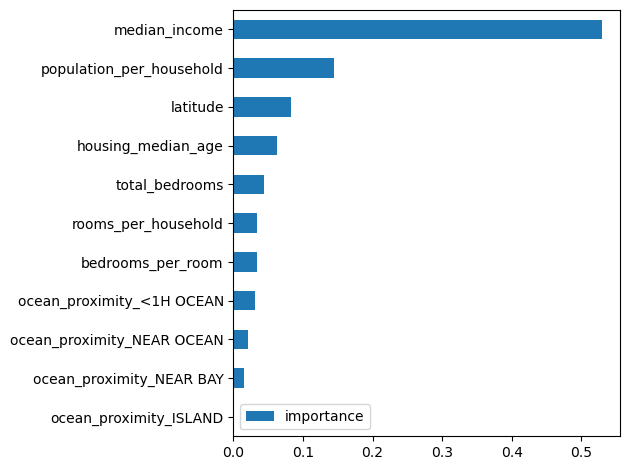

In [126]:
# Understanding the Feature Importance
%matplotlib inline
imp = pd.DataFrame({'importance': Random_Forest['randomforest'].feature_importances_})
imp.index = train_X.columns
imp.sort_values('importance',inplace=True)
imp.plot(kind='barh')

'condition','model_family','days_since_last_purchase','first_time_customer','sales_person', are considered to be important and in grid search

##### Pipeline build based on new importance features

In [127]:
# let's find features for some decent defaults
imp_features = ['latitude',
 'rooms_per_household',
 'ocean_proximity_NEAR OCEAN',
 'bedrooms_per_room',
 'ocean_proximity_ISLAND',
 'ocean_proximity_NEAR BAY',
 'population_per_household',
 'ocean_proximity_<1H OCEAN',
 'median_income',
 'housing_median_age',
 'total_bedrooms']

estimator = RandomForestRegressor()
xgb_training_pipe2 = Pipeline([
    ('randomforest_imp_features', RandomForestRegressor())
])

#### Grid Search of the Estimator

In [128]:
parameters = app_config["RandomForest"]["parameters"]

In [129]:
parameters

{'n_estimators': [50, 100, 200],
 'max_depth': ['None', 10, 20],
 'min_samples_split': [2, 5, 10],
 'min_samples_leaf': [1, 2, 4]}

In [130]:
%%time
est = RandomForestRegressor()
RF_grid = GridSearchCV(est,
                        parameters,
                        cv = 2,
                        n_jobs = 4,
                        verbose=True)

RF_grid.fit(train_X, train_y)

print(RF_grid.best_score_)
print(RF_grid.best_params_)

Fitting 2 folds for each of 81 candidates, totalling 162 fits



54 fits failed out of a total of 162.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
54 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\pranathi.paruchu\Anaconda3\envs\ta-lib_housing-dev\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\pranathi.paruchu\Anaconda3\envs\ta-lib_housing-dev\lib\site-packages\sklearn\ensemble\_forest.py", line 450, in fit
    trees = Parallel(
  File "c:\Users\pranathi.paruchu\Anaconda3\envs\ta-lib_housing-dev\lib\site-packages\joblib\parallel.py", line 1863, in __call__
    return output if self.return_generator else list(output)
  File "c:\Users\pranathi.paruchu

0.7632757847781958
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
CPU times: total: 23.9 s
Wall time: 5min 32s


#### Pipeline Build using the best estimator

In [131]:
rf_pipeline_final = Pipeline([('RandomForest_BEST', RF_grid.best_estimator_)
])
rf_pipeline_final.fit(train_X, train_y)

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Pipeline(steps=[('RandomForest_BEST',
                 RandomForestRegressor(max_depth=20, min_samples_split=5,
                                       n_estimators=200))])

In [132]:
reg_tree_report = RegressionReport(model=rf_pipeline_final, x_train=train_X, y_train=train_y, x_test= test_X, y_test= test_y)
reg_tree_report.get_report(include_shap=False, file_path='regression_tree_model_report')

Attribute `_pairwise` was deprecated in version 0.24 and will be removed in 1.1 (renaming of 0.26).
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
this method is deprecated in favour of `Styler.to_html()`


The Regression report containing the feature importances are available [here](https://drive.google.com/file/d/1JBfL3uxPcxBfl0amweXBFmLr7CSHFBUO/view?usp=sharing)

### Decision Tree

In [133]:
# let's find features for some decent defaults
dt_estimator = DecisionTreeRegressor()
dt_training_pipe_init = Pipeline([
    ('DecisionTree', DecisionTreeRegressor())
])
dt_training_pipe_init.fit(train_X, train_y)

Pipeline(steps=[('DecisionTree', DecisionTreeRegressor())])

In [134]:
reg_linear_report = RegressionReport(model=dt_training_pipe_init, x_train=train_X, y_train=train_y, x_test= test_X, y_test= test_y, refit=True)
reg_linear_report.get_report(include_shap=False, file_path='regression_decisiontree_model_report')

Attribute `_pairwise` was deprecated in version 0.24 and will be removed in 1.1 (renaming of 0.26).
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
divide by zero encountered in true_divide
invalid value encountered in multiply
invalid value encountered in true_divide
this method is deprecated in favour of `Styler.to_html()`


# 5 Model Comparison

Now, a comparison report of the  linear (vs) tree -based model  approach can be generated as follows.

This code will not be part of the production code.

In [135]:
model_pipelines = [reg_ppln,dt_training_pipe_init,Random_Forest,rf_pipeline_final]
model_comparison_report = RegressionComparison(models=model_pipelines,x=train_X, y=train_y,refit=True)
#metrics = model_comparison_report.get_report(file_path='regression_comparison')

Attribute `_pairwise` was deprecated in version 0.24 and will be removed in 1.1 (renaming of 0.26).
Attribute `_pairwise` was deprecated in version 0.24 and will be removed in 1.1 (renaming of 0.26).
Attribute `_pairwise` was deprecated in version 0.24 and will be removed in 1.1 (renaming of 0.26).
Attribute `_pairwise` was deprecated in version 0.24 and will be removed in 1.1 (renaming of 0.26).


In [136]:
model_comparison_report.feature_importances()

{'Linear Regression': :Bars   [index]   (importance),
 'DecisionTree': :Bars   [index]   (importance),
 'randomforest': :Bars   [index]   (importance),
 'RandomForest_BEST': :Bars   [index]   (importance)}

In [137]:
model_comparison_report.perf_metrics()


A report comparing the performance, metrics between Linear model and Tree model are available [here](https://drive.google.com/file/d/1LDibiFap9K4DKME-Y0S0mtI_05lTdaJF/view?usp=sharing)

**Dev NOTES**
<details>

the above metrics are absolute nos and not %ges

In this example we are choosing LM model for pipelining. General criteria for choosing production models is:

- Parametric models (aka whitebox models) such as Linear Regression are easier to explain to non-technical audience.
- Generally these are accepted fast and adoption is quicker.
- If the downstream calls for optimization using these models parametric models are easier to implement.
- When accuracy is primary goal without explainability, the above two takes a backseat